# RobustMedCT_ECU

Sources: https://www.kaggle.com/competitions/robust-med-ct-2025/data

### Dataset Description
The dataset used in this challenge is a modified subset of the OrganAMNIST dataset, which originates from abdominal CT scans. Each image has been preprocessed into a small, standardized format to ensure fairness and accessibility for all participants.

#### Data Characteristics
Modality: Grayscale abdominal CT images
Resolution: 224 x224 pixels
Classes: 11 distinct organ categories
Labels: Each image is annotated with a class label (0–10), corresponding to a specific organ (Spleen, Right kidney, Left kidney, Gallbladder, Esophagus, Liver, Stomach, Aorta, Inferior vena cava, Pancreas, Right adrenal gland).
File Format: Images provided as .png files (or .npy arrays, depending on release format) with labels in accompanying metadata files
#### Data Splits
Training Set: Includes images and their corresponding organ labels.
Validation Set: Includes images and labels for model development and hyperparameter tuning.
Test Set: Includes only images (no labels provided). This set may contain challenging or atypical cases, including images with subtle digital alterations or noise, simulating real-world deployment scenarios.
#### Restrictions
No external datasets are permitted.
Participants must train and evaluate their models strictly on the data provided.
#### Purpose
This dataset has been intentionally designed to be compact yet challenging. While its resolution and size make it accessible to train models efficiently, the inclusion of atypical and digitally altered cases encourages participants to focus on robustness, generalization, and reliability rather than overfitting to clean data.

#### Link
https://edithcowanuni-my.sharepoint.com/:f:/g/personal/m_alfawareh_ecu_edu_au/EuY7TFbOy8BDqLZHvCuHFPgBUu-qvArs4dBpgw2Ue7CcqA

#### Imports & paths & load CSVs

In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Make plots show inline in Jupyter
%matplotlib inline

# ------------------------------------------------------------------
# 1) Define base directories (assuming your notebook is in RobustMedCT_ECU/)
# ------------------------------------------------------------------
BASE_DIR = Path("IS_2025_OrganAMNIST")

TRAIN_IMG_DIR = BASE_DIR / "train" / "images_train"
TRAIN_LABELS_CSV = BASE_DIR / "train" / "labels_train.csv"

VAL_IMG_DIR = BASE_DIR / "val" / "images_val"
VAL_LABELS_CSV = BASE_DIR / "val" / "labels_val.csv"

TEST_IMG_DIR = BASE_DIR / "test" / "images"
TEST_MANIFEST_CSV = BASE_DIR / "test" / "manifest_public.csv"

print("Train images dir:", TRAIN_IMG_DIR)
print("Train labels CSV:", TRAIN_LABELS_CSV)
print("Val images dir:  ", VAL_IMG_DIR)
print("Val labels CSV:  ", VAL_LABELS_CSV)
print("Test images dir: ", TEST_IMG_DIR)
print("Test manifest:   ", TEST_MANIFEST_CSV)

# ------------------------------------------------------------------
# 2) Load CSV files
# ------------------------------------------------------------------
train_df = pd.read_csv(TRAIN_LABELS_CSV)
val_df   = pd.read_csv(VAL_LABELS_CSV)
test_df  = pd.read_csv(TEST_MANIFEST_CSV)

print("\nTrain labels head:")
display(train_df.head())

print("\nVal labels head:")
display(val_df.head())

print("\nTest manifest head:")
display(test_df.head())

print("\nTrain shape:", train_df.shape,
      "| Val shape:", val_df.shape,
      "| Test shape:", test_df.shape)


Train images dir: IS_2025_OrganAMNIST\train\images_train
Train labels CSV: IS_2025_OrganAMNIST\train\labels_train.csv
Val images dir:   IS_2025_OrganAMNIST\val\images_val
Val labels CSV:   IS_2025_OrganAMNIST\val\labels_val.csv
Test images dir:  IS_2025_OrganAMNIST\test\images
Test manifest:    IS_2025_OrganAMNIST\test\manifest_public.csv

Train labels head:


,file,label
0,train_00000.png,6
1,train_00001.png,8
2,train_00002.png,5
3,train_00003.png,6
4,train_00004.png,9



Val labels head:


,file,label
0,val_00000.png,3
1,val_00001.png,6
2,val_00002.png,8
3,val_00003.png,6
4,val_00004.png,2



Test manifest head:


,index,file
0,0,test_00000.png
1,1,test_00001.png
2,2,test_00002.png
3,3,test_00003.png
4,4,test_00004.png



Train shape: (34561, 2) | Val shape: (6491, 2) | Test shape: (17778, 2)


Train CSV columns: ['file', 'label']
Train label distribution (counts):


label
0     1956
1     1390
2     1357
3     1474
4     3963
5     3817
6     6164
7     3919
8     3929
9     3031
10    3561
Name: count, dtype: int64

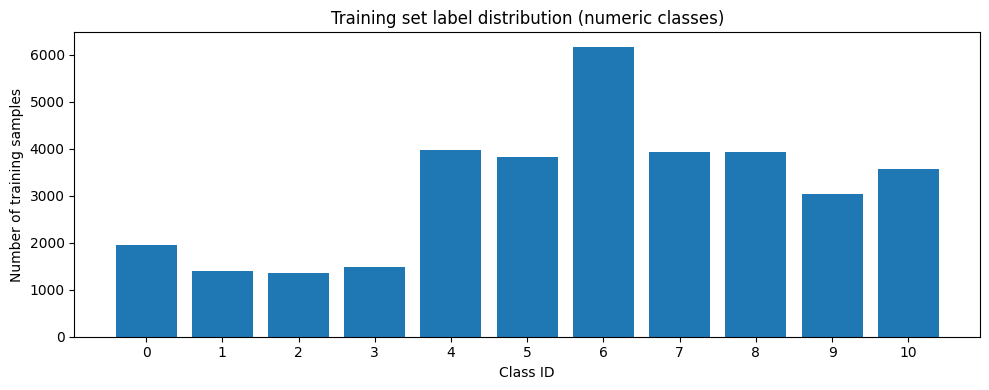

In [2]:
# ------------------------------------------------------------------
# 3) Define which columns are file names and labels
# ------------------------------------------------------------------

print("Train CSV columns:", train_df.columns.tolist())

FILE_COL = "file"       
LABEL_COL = "label"     

if LABEL_COL not in train_df.columns:
    raise ValueError(f"Label column '{LABEL_COL}' not found in train_df.columns: {train_df.columns}")

# ------------------------------------------------------------------
# 4) Compute train label distribution (numeric class IDs only)
# ------------------------------------------------------------------
class_counts = train_df[LABEL_COL].value_counts().sort_index()

print("Train label distribution (counts):")
display(class_counts)

plt.figure(figsize=(10, 4))
x = class_counts.index
y = class_counts.values

plt.bar(x, y)

# Use numeric class IDs as x-axis tick labels
xticklabels = [str(int(c)) for c in x]
plt.xticks(x, xticklabels, rotation=0)

plt.xlabel("Class ID")
plt.ylabel("Number of training samples")
plt.title("Training set label distribution (numeric classes)")
plt.tight_layout()
plt.show()


#### Data Augmenting

In [3]:
import torchvision.transforms as T

IMG_SIZE = 224  # images are 224x224 according to the description

# -------------------------
# Training-time transforms
# -------------------------
train_transform = T.Compose([
    # 1) Basic resizing to the target size
    T.Resize((IMG_SIZE, IMG_SIZE)),
    
    # 2) Geometric transforms (safe for left/right anatomy)
    #    - Vertical flip is OK (does not swap left/right)
    #    - Small random rotation + slight translation/scale
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=15),  # small rotations, not 90/180
    
    T.RandomAffine(
        degrees=0,                 # no extra rotation here (already above)
        translate=(0.05, 0.05),    # up to 5% translation in each direction
        scale=(0.9, 1.1),          # small scaling
        shear=None
    ),
    
    # 3) Intensity / robustness-related transforms
    #    Simulate corruptions: contrast/brightness changes, blur, noise
    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
    ),
    
    T.RandomApply(
        [T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))],
        p=0.3,  # apply blur with 30% probability
    ),
    
    # (Optional) simple "cutout"-style augment
    # T.RandomErasing(p=0.2, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
    
    # 4) To tensor + normalization
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
])

# -------------------------
# Validation / test transforms (no heavy aug)
# -------------------------
val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
])

print("Transforms ready.")


C:\Users\Li\PycharmProjects\OKTI\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Transforms ready.


#### Model Training


In [4]:
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
import torch
import numpy as np

# Basic training params
BATCH_SIZE = 128
NUM_WORKERS = 4

# Make sure these match your CSV column names (should already be set in previous cells)
FILE_COL = "file"
LABEL_COL = "label"

# -------------------------
# Custom Dataset
# -------------------------
class RobustMedCTDataset(Dataset):
    """
    Simple dataset for the RobustMedCT_ECU challenge.
    Assumes:
      - df has columns [FILE_COL, LABEL_COL]
      - image files are located under img_dir / <file_name>
      - images are single-channel (grayscale)
    """
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fname = row[FILE_COL]
        label = int(row[LABEL_COL])

        img_path = self.img_dir / fname
        img = Image.open(img_path).convert("L")  # grayscale

        if self.transform is not None:
            img = self.transform(img)

        return img, label

# -------------------------
# Class-balanced sampling with WeightedRandomSampler
# -------------------------
class_counts = train_df[LABEL_COL].value_counts().sort_index()
print("Class counts:\n", class_counts)

class_weights = 1.0 / class_counts.values.astype(np.float32)
label_to_weight = {cls: w for cls, w in zip(class_counts.index, class_weights)}

sample_weights = train_df[LABEL_COL].map(label_to_weight).values
sample_weights = torch.from_numpy(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,   # allow samples to be drawn multiple times per epoch
)

# -------------------------
# Create Datasets & DataLoaders
# -------------------------
train_ds = RobustMedCTDataset(train_df, TRAIN_IMG_DIR, transform=train_transform)
val_ds   = RobustMedCTDataset(val_df,   VAL_IMG_DIR,   transform=val_transform)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,   # use sampler for balanced sampling
    shuffle=False,     # must be False when sampler is used
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

num_classes = train_df[LABEL_COL].nunique()
print(f"Num classes: {num_classes}")
print("DataLoaders are ready.")


Class counts:
 label
0     1956
1     1390
2     1357
3     1474
4     3963
5     3817
6     6164
7     3919
8     3929
9     3031
10    3561
Name: count, dtype: int64
Num classes: 11
DataLoaders are ready.


In [ ]:
from torchvision import models
from torch import nn
from sklearn.metrics import accuracy_score, f1_score
from tqdm.notebook import tqdm
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -------------------------
# Build model (ResNet18 -> 1-channel input + num_classes output)
# -------------------------
def build_resnet18(num_classes, use_pretrained=True):
    if use_pretrained:
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    else:
        model = models.resnet18(weights=None)
    
    # Change first conv to accept 1-channel input instead of 3
    w = model.conv1.weight.data
    model.conv1 = nn.Conv2d(
        in_channels=1,
        out_channels=model.conv1.out_channels,
        kernel_size=model.conv1.kernel_size,
        stride=model.conv1.stride,
        padding=model.conv1.padding,
        bias=False,
    )
    model.conv1.weight.data = w.mean(dim=1, keepdim=True)  # average over RGB
    
    # Replace final FC layer
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

model = build_resnet18(num_classes=num_classes, use_pretrained=True)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# -------------------------
# Helper: evaluate on validation set
# -------------------------
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, f1

# -------------------------
# Training loop
# -------------------------
NUM_EPOCHS = 20
best_val_f1 = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    
    for x, y in tqdm(train_loader, desc=f"Epoch {epoch}", leave=False):
        x = x.to(device)
        y = y.to(device)
        
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * x.size(0)
    
    train_loss = total_loss / len(train_loader.dataset)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader)
    epoch_time = time.time() - epoch_start
    
    print(f"Epoch {epoch:02d} | "
          f"train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | "
          f"val_acc={val_acc:.4f} | "
          f"val_f1={val_f1:.4f}  | "
          f"time={epoch_time:.1f}s")
    
    # Save the best model based on validation macro-F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(
            {"model_state": model.state_dict(), "num_classes": num_classes},
            "best_resnet18_robustmedct.pth",
        )
        print("  -> New best model saved.")


Device: cuda


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Li/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:01<00:00, 37.8MB/s]


#### Test Inference and Submission CSV FIle Generation

In [ ]:
# ------ Test dataset & dataloader (updated) ------

class RobustMedCTTestDataset(Dataset):
    """
    Test dataset (no labels).
    Expects a DataFrame with columns: 'index', 'file'.
    Returns (image_tensor, index_int).
    """
    def __init__(self, df, img_dir, transform=None,
                 index_col="index", file_col="file"):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.index_col = index_col
        self.file_col = file_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        idx = int(row[self.index_col])
        fname = row[self.file_col]

        img_path = self.img_dir / fname
        img = Image.open(img_path).convert("L")  # grayscale

        if self.transform is not None:
            img = self.transform(img)

        return img, idx

print(test_df.head())

test_ds = RobustMedCTTestDataset(
    test_df,
    TEST_IMG_DIR,
    transform=val_transform,  # use validation transform (no heavy aug)
    index_col="index",
    file_col="file",
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print("Num test images:", len(test_ds))


In [ ]:
# ------ Load best checkpoint ------

ckpt_path = "best_resnet18_robustmedct.pth"
ckpt = torch.load(ckpt_path, map_location=device)

num_classes_ckpt = ckpt.get("num_classes", num_classes)
print("num_classes in checkpoint:", num_classes_ckpt)

model = build_resnet18(num_classes=num_classes_ckpt, use_pretrained=False)
model.load_state_dict(ckpt["model_state"])
model = model.to(device)
model.eval()

print("Checkpoint loaded.")

# ------ Inference on test set ------

all_indices = []
all_preds = []

with torch.no_grad():
    for imgs, indices in tqdm(test_loader, desc="Inference on test"):
        imgs = imgs.to(device)
        logits = model(imgs)
        preds = logits.argmax(dim=1).cpu().numpy()

        for idx_val, pred in zip(indices, preds):
            all_indices.append(int(idx_val))
            all_preds.append(int(pred))

print("First 10 predictions:", list(zip(all_indices, all_preds))[:10])
print("Total predictions:", len(all_preds))


In [ ]:
# ------ Build submission DataFrame in the required format ------

submission = pd.DataFrame({
    "index": all_indices,
    "id": all_preds,   # Kaggle wants column name 'id'
})

# Sort by index just to be safe
submission = submission.sort_values("index").reset_index(drop=True)

print(submission.head())
print(submission.tail())

submission_path = "submission.csv"  # required filename
submission.to_csv(submission_path, index=False)
print(f"Submission file saved to: {submission_path}")
